Text(0.5, 1.0, 'Attitude (deg)')

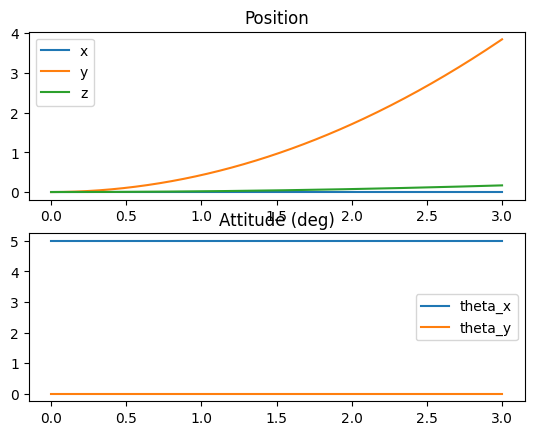

In [1]:
# In a notebook cell
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from dynamics import nonlinear_dynamics, mass, gravity

def open_loop_wrapper(t, x):
    u = np.array([mass * gravity, 0, 0, 0])  # hover thrust, no gimbal
    return nonlinear_dynamics(x, u)

x0 = np.zeros(12)
x0[6] = np.radians(5)   # start tilted 5 degrees about body X

sol = solve_ivp(open_loop_wrapper, [0, 3], x0, max_step=0.01)

# Plot position and attitude over time
fig, ax = plt.subplots(2, 1)
ax[0].plot(sol.t, sol.y[0], label='x')
ax[0].plot(sol.t, sol.y[1], label='y')
ax[0].plot(sol.t, sol.y[2], label='z')
ax[0].legend()
ax[0].set_title('Position')

ax[1].plot(sol.t, np.degrees(sol.y[6]), label='theta_x')
ax[1].plot(sol.t, np.degrees(sol.y[7]), label='theta_y')
ax[1].legend()
ax[1].set_title('Attitude (deg)')